# Tidal Analysis 

In [2]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy.signal import find_peaks

tide = pd.read_csv('../data/water_levels/QUINTA_tides.csv', index_col=0, parse_dates=True).iloc[:, 0].rename('tide_m')
tide.index = pd.to_datetime(tide.index).tz_localize(None)
print(tide.describe(), '\nstep:', tide.index.to_series().diff().mode()[0])

count    1.495969e+06
mean    -6.738817e-04
std      3.932705e-01
min     -9.378511e-01
25%     -3.310366e-01
50%      3.909512e-05
75%      3.297151e-01
max      9.736222e-01
Name: tide_m, dtype: float64 
step: 0 days 00:15:00


In [4]:
STEP = tide.index.to_series().diff().mode()[0]
per_cycle = int(pd.Timedelta('4h') / pd.Timedelta(STEP))   # min spacing between turning points

ih, _ = find_peaks(tide.values,  distance=per_cycle)
il, _ = find_peaks(-tide.values, distance=per_cycle)
hw = tide.iloc[ih]
lw = tide.iloc[il]
print(f'{len(hw):,} high waters, {len(lw):,} low waters')

# higher/lower of each tidal day, for the diurnal-inequality datums
hhw = hw.groupby(hw.index.normalize()).max()
lhw = hw.groupby(hw.index.normalize()).min()
llw = lw.groupby(lw.index.normalize()).min()
hlw = lw.groupby(lw.index.normalize()).max()

30,111 high waters, 30,111 low waters


In [6]:
fortnight = ((tide.index - tide.index[0]) / pd.Timedelta('14.765D')).astype(int)
fn_hw = pd.Series(fortnight, index=tide.index).reindex(hw.index)
fn_lw = pd.Series(fortnight, index=tide.index).reindex(lw.index)

datums = pd.Series({
    'HAT':  tide.max(),
    'MHWS': hw.groupby(fn_hw).max().mean(),
    'MHHW': hhw.mean(),
    'MHW':  hw.mean(),
    'MHWN': hw.groupby(fn_hw).min().mean(),
    'MSL':  tide.mean(),
    'MLWN': lw.groupby(fn_lw).max().mean(),
    'MLW':  lw.mean(),
    'MLLW': llw.mean(),
    'MLWS': lw.groupby(fn_lw).min().mean(),
    'LAT':  tide.min(),
}).round(3)

print(datums.to_string())
print(f'\nmean range (MHW-MLW):    {datums.MHW - datums.MLW:.2f} m')
print(f'spring range (MHWS-MLWS): {datums.MHWS - datums.MLWS:.2f} m')
print(f'neap range (MHWN-MLWN):   {datums.MHWN - datums.MLWN:.2f} m')
print(f'great diurnal range:      {datums.MHHW - datums.MLLW:.2f} m')

HAT     0.974
MHWS    0.751
MHHW    0.573
MHW     0.529
MHWN    0.287
MSL    -0.001
MLWN   -0.280
MLW    -0.531
MLLW   -0.594
MLWS   -0.783
LAT    -0.938

mean range (MHW-MLW):    1.06 m
spring range (MHWS-MLWS): 1.53 m
neap range (MHWN-MLWN):   0.57 m
great diurnal range:      1.17 m


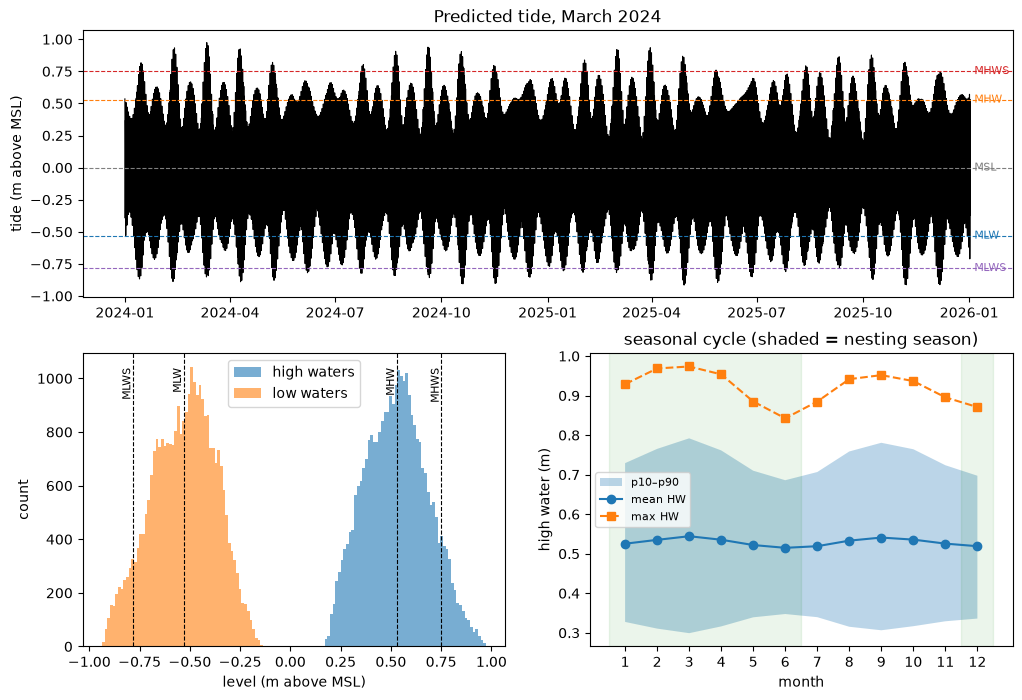

In [11]:
fig = plt.figure(figsize=(12, 8))
gs = fig.add_gridspec(2, 2, height_ratios=[1, 1.1])

# (a) one spring-neap cycle
ax = fig.add_subplot(gs[0, :])
seg = tide.loc['2024-01-01':'2026-01-01']
ax.plot(seg.index, seg.values, lw=0.8, color='k')
for name, c in [('MHWS', 'C3'), ('MHW', 'C1'), ('MSL', 'C7'), ('MLW', 'C0'), ('MLWS', 'C4')]:
    ax.axhline(datums[name], color=c, lw=0.8, ls='--')
    ax.text(seg.index[-1], datums[name], f' {name}', va='center', fontsize=8, color=c)
ax.set_ylabel('tide (m above MSL)'); ax.set_title('Predicted tide, March 2024')

# (b) distribution of high and low waters
ax = fig.add_subplot(gs[1, 0])
ax.hist(hw.values, bins=60, alpha=.6, label='high waters')
ax.hist(lw.values, bins=60, alpha=.6, label='low waters')
for name in ['MHWS', 'MHW', 'MLW', 'MLWS']:
    ax.axvline(datums[name], color='k', lw=0.8, ls='--')
    ax.text(datums[name], ax.get_ylim()[1]*0.95, name, rotation=90, fontsize=8, ha='right', va='top')
ax.set_xlabel('level (m above MSL)'); ax.set_ylabel('count'); ax.legend()

# (c) seasonal cycle of high water
ax = fig.add_subplot(gs[1, 1])
m = hw.groupby(hw.index.month)
ax.fill_between(range(1, 13), m.quantile(.1), m.quantile(.9), alpha=.3, label='p10–p90')
ax.plot(range(1, 13), m.mean(), 'o-', label='mean HW')
ax.plot(range(1, 13), m.max(), 's--', label='max HW')
ax.axvspan(0.5, 6.5, color='green', alpha=.08)      # Dec–Jun nesting season (Jan–Jun portion)
ax.axvspan(11.5, 12.5, color='green', alpha=.08)
ax.set_xticks(range(1, 13)); ax.set_xlabel('month'); ax.set_ylabel('high water (m)')
ax.set_title('seasonal cycle (shaded = nesting season)'); ax.legend(fontsize=8)